In [ ]:
import pandas as pd

# pd.set_option('display.max_columns', None)  # none은 제한값 자리(몇개 열까지 보여줄까)
# pd.set_option('display.max_rows', None)

# 집에서 df 경로: r'C:\Users\soohok402\내 드라이브\Github\AI_Data_exhibition\parqueted_data\train.parquet'
# 회사에서 df 경로: r'C:\Users\20162180\AI_Data_exhibition\parqueted_data\train.parquet'

df = pd.read_parquet(r'C:\Users\soohok402\내 드라이브\Github\AI_Data_exhibition\parqueted_data\train.parquet')

# 해당 df의 메모리사용량 확인용
# df.memory_usage(deep=True).sum() / 1024**3

In [2]:
# 메모리 사용 중 객체 불러오기
%whos

Variable   Type         Data/Info
---------------------------------
df         DataFrame    Shape: (749657, 25)
pd         module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>


In [6]:
# 컬럼 분리하기

# 시계열 컬럼군
time_cols = ['wl_t',          # 수위데이터 대표
        'sfc_rain_1h',   # 육상 누적강수데이터 대표
        'imerg_rain_1h', # 레이더 누적강수데이터 대표
        'radar_reflectivity_mean', # 레이더반사도 대표
        'radar_reflectivity_p95', # 레이더반사도 대표
        'target_maxrise_6h' # 종속변수: 수위상승량
        ]

# 수위 컬럼군
wl_cols = ['wl_t',
          'wl_t_minus_1h',
          'wl_t_minus_3h',
          'wl_t_minus_6h',
          'wl_t_minus_12h',
          'wl_t_minus_24h',
          ]

# 강수 컬럼군
rain_cols = [
            # IMERG강우
            'imerg_rain_1h',
            'imerg_rain_6h',
            'imerg_rain_24h',
            # 지상강우
            'sfc_rain_1h',
            'sfc_rain_6h',
            'sfc_rain_24h',
            # 레이더 반사도
            'radar_reflectivity_mean',
            'radar_reflectivity_p95',
            'radar_reflectivity_ge20_fraction'
]

# 환경 컬럼군
env_cols = [
    'cat_area',       # km²
    'wsarea',         # km²
    'mean_elevation', # m
    'mean_slope',     # °
    'urban_ratio',    # %
    'forest_ratio',   # %
    'stream_order'
]

In [7]:
# ============================================================
# 1. 기본 구조 확인
# ============================================================
# - 데이터 크기(shape), 컬럼명, 자료형 확인
# print(f"데이터 크기: {df.shape}")
print()
# print(f"자료형: \n{df.dtypes}")  # row_id, station_id만 object, 나머지는 수치형
print()

# - 데이터 일부(head) 확인
# print(df.head())
print()

# - 기술통계(describe) 확인: 결과는 #1
df_describe = df.describe(include = 'all')  # include = 'all'은 비수치형자료도 포함 의미
print(df_describe)


# mean >> 50%(median)인 변수가 많음, 시각화 필요
skew = df.select_dtypes(include = 'number').skew().sort_values(ascending = False)
print(skew)  # 왜도는 양수면 우측꼬리 긴 우편향, 절대값 > 1부터는 왜도가 있다고 봄





                            timestamp station_id           wl_t  \
count                          749657     749657  749657.000000   
unique                            NaN        465            NaN   
top                               NaN     ST0449            NaN   
freq                              NaN       1676            NaN   
mean    2102-04-11 01:45:19.070721536        NaN       4.059135   
min               2100-01-01 00:00:00        NaN      -3.840000   
25%               2101-03-07 22:00:00        NaN       0.620000   
50%               2102-06-10 15:00:00        NaN       1.130000   
75%               2103-06-06 13:00:00        NaN       1.970000   
max               2104-02-20 13:00:00        NaN     139.640000   
std                               NaN        NaN      13.371356   

        wl_t_minus_1h  wl_t_minus_3h  wl_t_minus_6h  wl_t_minus_12h  \
count   749657.000000   749657.00000  749657.000000   749657.000000   
unique            NaN            NaN            Na

In [ ]:
# 데이터가 시계열데이터와 환경데이터가 섞여있음
# 분리해서 시계열데이터는 전체 데이터에 대해, 환경데이터는 관측소별로 groupby 한 후에 EDA 진행

# 시계열데이터 박스플롯과 히스토그램 그리기

import matplotlib.pyplot as plt

# time_cols = ['wl_t',          # 수위데이터 대표
#         'sfc_rain_1h',   # 육상 누적강수데이터 대표
#         'imerg_rain_1h', # 레이더 누적강수데이터 대표
#         'radar_reflectivity_mean', # 레이더반사도 대표
#         'radar_reflectivity_p95', # 레이더반사도 대표
#         'target_maxrise_6h' # 종속변수: 수위상승량
#         ]

fig, axes = plt.subplots( # 반환객체 두가지: fig는 전체 도화지, axes는 내부배열
    len(time_cols),   # 행 개수
    2,           # 열 개수
    figsize = (12, 4 * len(time_cols))) # 전체 크기(가로×세로, 인치) 튜플로 넣기
# 기본적으로 열 개수가 2이므로 axes는 한 행당 두개의 ax를 반환

if len(time_cols) == 1: # cols에 한개 열만 오면 axes = [ax1, ax2]만 반환
    axes = [axes]  # axes = [[ax1, ax2]]가 돼야 행열(0행 0, 1열) 접근이 가능

for i, col in enumerate(time_cols):
    x = df[col].dropna()  # 플롯을 여러개 그릴 예정, 플롯할 데이터를 하나의 변수로 묶어놓기(col임을 주의)

    axes[i][0].boxplot(x)
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)  # tick은 눈금을 의미, tick_params는 눈금설정값
    
    axes[i][1].hist(x, bins = 30)  # bins는 x축을 나눌 구간 개수
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)

plt.tight_layout()  # 자동 간격조정(배치관리)
plt.show()


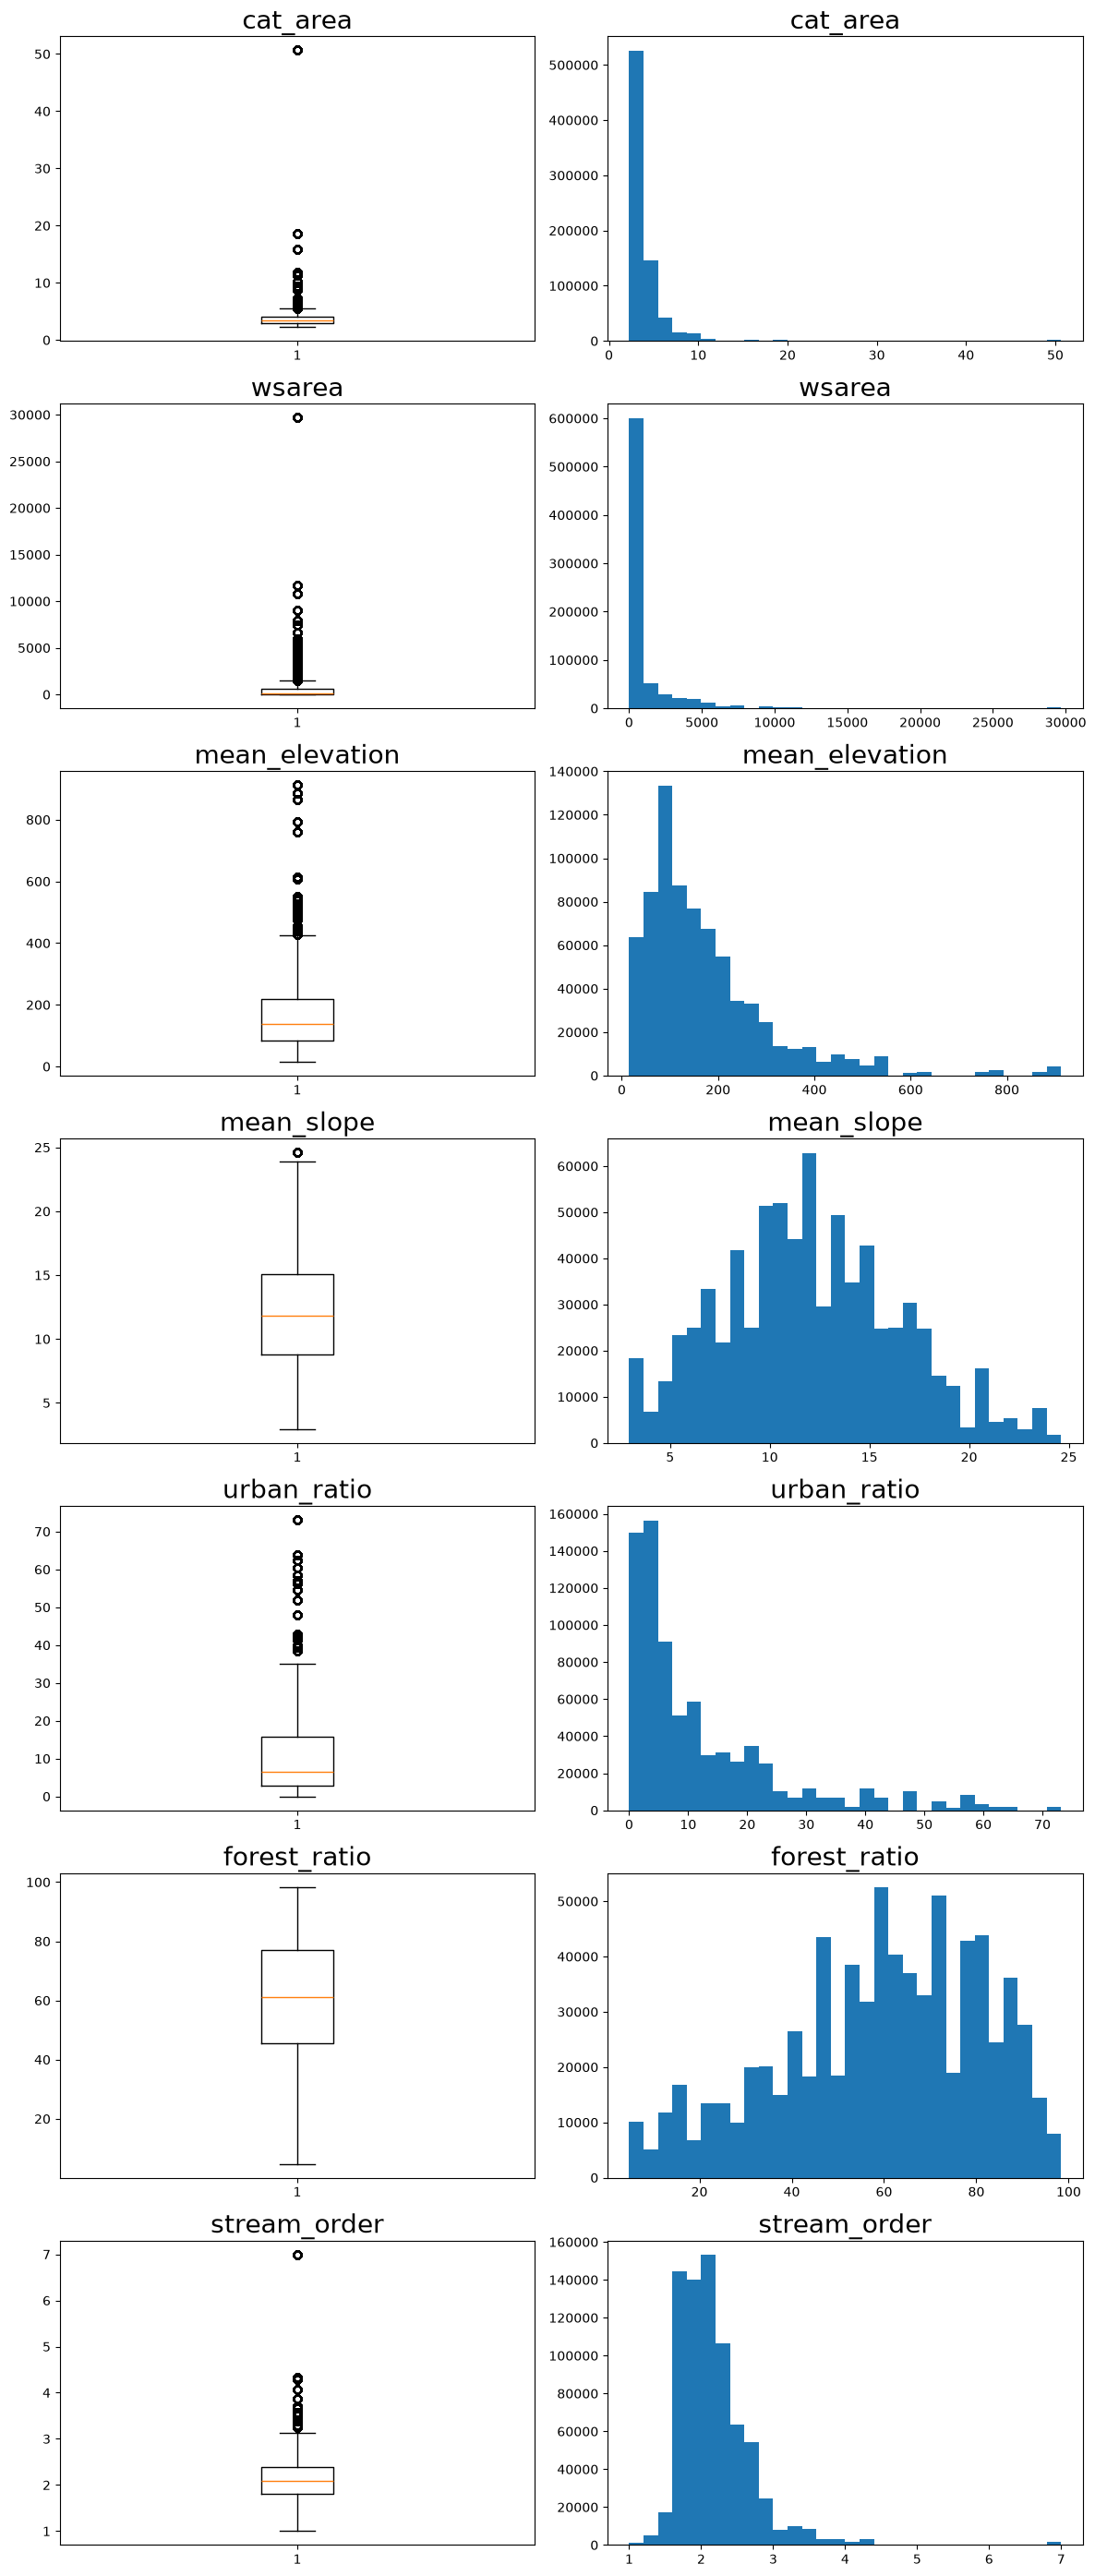

In [ ]:
# 데이터가 시계열데이터와 환경데이터가 섞여있음
# 환경데이터는 관측소에 따라 고정값이므로 따로 groupby를 해서 EDA를 진행

# env_cols = [
#     'cat_area',       # km²
#     'wsarea',         # km²
#     'mean_elevation', # m
#     'mean_slope',     # °
#     'urban_ratio',    # %
#     'forest_ratio',   # %
#     'stream_order'
# ]

# df.groupby("station_id")[env_cols].nunique().max()
# nunique() 고유값 개수 반환, unique()는 고유값 목록을 반환
# max()를 붙여서 1보다 큰 컬럼이 있으면 고유값이 아닌게 있다는 것

env_gb = df.groupby('station_id')[env_cols]
# print(env_gb.nunique().max())  
# nunique()가 1이면 해당인덱스가 갖는 범주가 하나밖에 없다는 뜻, 모두 1이면 식별자인거지
# 고유값 개수가 모두 1이므로 first() 첫값만 꺼내기: 그럼 같은 그룹으로 묶인 것 중에는 첫값만 나옴
env_gb_df = env_gb.first()
env_gb_df

# 이제 이걸로 EDA를 한다.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    len(env_cols),
        2,
        figsize = (12, 4 * len(env_cols))
)

if len(env_cols) == 1:
    axes = [axes]

for i, col in enumerate(env_cols):
    x = df[col].dropna()

    axes[i][0].boxplot(x)
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)

    axes[i][1].hist(x, bins = 30)
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)

    
plt.tight_layout()
plt.show()

In [ ]:
# 시계열데이터 중에 수위와 강수데이터는 여러가지가 섞여있음
# 왜도나 중앙값, 평균은 비슷하지만 이상치는 개별적으로 확인이 필요함
# describe 함수의 일부를 불러오고자 함

# print(df_describe)
print(df_describe[wl_cols + rain_cols].loc[['max', 'min']])

       wl_t  wl_t_minus_1h  wl_t_minus_3h  wl_t_minus_6h  wl_t_minus_12h  \
max  139.64         139.69         139.75         139.90          140.14   
min   -3.84          -3.90          -3.90          -3.81           -3.91   

     wl_t_minus_24h  imerg_rain_1h  imerg_rain_6h  imerg_rain_24h  \
max          140.58         114.53        313.557         371.228   
min           -3.90           0.00          0.000           0.000   

     sfc_rain_1h  sfc_rain_6h  sfc_rain_24h  radar_reflectivity_mean  \
max         87.0        290.5         390.0                   55.917   
min          0.0          0.0           0.0                    0.000   

     radar_reflectivity_p95  radar_reflectivity_ge20_fraction  
max                   67.77                               1.0  
min                    0.00                               0.0  


In [ ]:
# ============================================================
# 2. 데이터 품질 확인
# ============================================================
# - 중복 데이터 확인
# - 결측치 개수 및 비율 확인
missing = df.isnull().sum()  # 크기순으로 정렬하려면 sort_values(ascending = True 추가)
print(missing)

# - 이상치 후보 확인


row_id                              0
timestamp                           0
station_id                          0
wl_t                                0
wl_t_minus_1h                       0
wl_t_minus_3h                       0
wl_t_minus_6h                       0
wl_t_minus_12h                      0
wl_t_minus_24h                      0
imerg_rain_1h                       0
imerg_rain_6h                       0
imerg_rain_24h                      0
sfc_rain_1h                         0
sfc_rain_6h                         0
sfc_rain_24h                        0
radar_reflectivity_mean             0
radar_reflectivity_p95              0
radar_reflectivity_ge20_fraction    0
cat_area                            0
wsarea                              0
mean_elevation                      0
mean_slope                          0
urban_ratio                         0
forest_ratio                        0
stream_order                        0
target_maxrise_6h                   0
dtype: int64

In [ ]:
# ============================================================
# 5. 독립변수와 Target 간 관계 확인
# ============================================================
# - 수위 변수와 Target 관계 확인
# - 강우 변수와 Target 관계 확인
# - 유역환경 변수와 Target 관계 확인
# - 상관계수 및 시각화를 통해 주요 변수 후보 탐색